# Model 1: CatBoost

In [1]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix

from src.preprocessing import PreprocessConfig, preprocess_train_test

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)
pd.set_option("display.max_rows", 250)

RANDOM_STATE = 42

In [2]:
# Load raw → preprocess for CatBoost

TRAIN_PATH = "D:\\dataorg-financial-health-prediction-challenge20251204-19827-m2tn1n\\Train.csv"
TEST_PATH  = "D:\\dataorg-financial-health-prediction-challenge20251204-19827-m2tn1n\\Test.csv"

train_raw = pd.read_csv(TRAIN_PATH)
test_raw  = pd.read_csv(TEST_PATH)

cfg = PreprocessConfig(id_col="ID", target_col="Target")

train, test = preprocess_train_test(train_raw, test_raw, cfg, for_model="catboost")

TARGET = cfg.target_col
ID = cfg.id_col

print("train:", train.shape, "| test:", test.shape)
train.head()

train: (9618, 47) | test: (2405, 46)


,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,business_turnover,business_age_years,motor_vehicle_insurance,has_mobile_money,current_problem_cash_flow,has_cellphone,owner_sex,offers_credit_to_customers,attitude_satisfied_with_achievement,has_credit_card,keeps_financial_records,perception_insurance_companies_dont_insure_businesses_like_yours,perception_insurance_important,has_insurance,covid_essential_service,attitude_more_successful_next_year,problem_sourcing_money,marketing_word_of_mouth,has_loan_account,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender,Target,personal_income_missing,business_expenses_missing,business_turnover_missing,log_personal_income,log_business_expenses,log_business_turnover,business_age_total_months,business_age_months_ge_12
0,ID_3CFL0U,eswatini,63.0,yes,no,no,no,yes,3000.0,6000.0,7000.0,14.0,never had,have now,yes,yes,male,"yes, sometimes",no,never had,"yes, always",yes,yes,no,yes,yes,yes,yes,never had,never had,never had,NaN,6.0,never had,used to have but don't have now,NaN,never had,never had,Low,0,0,0,8.006701,8.699681,8.853808,174.0,0
1,ID_XWI7G3,zimbabwe,39.0,no,yes,yes,no,yes,NaN,NaN,NaN,15.0,have now,have now,NaN,yes,male,"yes, sometimes",yes,never had,"yes, always",no,yes,yes,yes,NaN,NaN,NaN,NaN,NaN,NaN,no,3.0,never had,never had,NaN,NaN,NaN,Medium,1,1,1,NaN,NaN,NaN,183.0,0
2,ID_TY93LV,malawi,34.0,don't know,no,no,don't know,yes,30000.0,6000.0,13000.0,5.0,NaN,never had,yes,yes,male,"yes, sometimes",yes,never had,no,don't know,yes,no,NaN,yes,yes,no,never had,never had,never had,yes,NaN,NaN,NaN,yes,NaN,NaN,Low,0,0,0,10.308986,8.699681,9.472782,60.0,0
3,ID_9OP2C8,malawi,28.0,yes,no,no,no,no,180000.0,60000.0,30000.0,1.0,NaN,have now,no,yes,female,"yes, sometimes",no,never had,no,no,yes,no,NaN,yes,no,no,never had,never had,never had,no,NaN,NaN,NaN,yes,never had,have now,Low,0,0,0,12.100718,11.002117,10.308986,12.0,0
4,ID_13REYS,zimbabwe,43.0,yes,no,no,yes,yes,50.0,2400.0,1800.0,3.0,never had,NaN,NaN,no,female,"yes, sometimes",yes,never had,no,yes,yes,no,no,NaN,NaN,NaN,NaN,NaN,NaN,no,0.0,never had,never had,yes,NaN,NaN,Low,0,0,0,3.931826,7.783641,7.496097,36.0,0


In [3]:
# Define X/y and categorical feature indices

y = train[TARGET]
X = train.drop(columns=[TARGET])

# Identify categorical columns (string/object)
cat_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical cols:", len(cat_cols))
print("Numeric cols:", len(num_cols))

# Indices for catboost Pool
cat_feature_indices = [X.columns.get_loc(c) for c in cat_cols]
cat_cols[:10], cat_feature_indices[:10]

Categorical cols: 32
Numeric cols: 14


(['ID',
  'country',
  'attitude_stable_business_environment',
  'attitude_worried_shutdown',
  'compliance_income_tax',
  'perception_insurance_doesnt_cover_losses',
  'perception_cannot_afford_insurance',
  'motor_vehicle_insurance',
  'has_mobile_money',
  'current_problem_cash_flow'],
 [0, 1, 3, 4, 5, 6, 7, 12, 13, 14])

In [4]:
# Class balance check + class weights
# CatBoost can use class weights. Because metric is macro F1, class imbalance matters.

class_counts = y.value_counts()
class_pct = (y.value_counts(normalize= True) * 100).round(2)
display(pd.DataFrame({"count": class_counts, "pct": class_pct}))

classes = class_counts.index.tolist()


,count,pct
Target,,
Low,6280,65.29
Medium,2868,29.82
High,470,4.89


In [5]:
# Inverse frequency weights (basic)

class_weights = (class_counts.sum() / (len(class_counts) * class_counts)).to_dict()
class_weights

{'Low': 0.5105095541401274,
 'Medium': 1.1178521617852162,
 'High': 6.821276595744681}

In [6]:
# Validation Strategy Setup

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

if "country" in X.columns:
    groups = X["country"]
    gkf = GroupKFold(n_splits=4)  # 4 countries
else:
    groups = None
    gkf = None

In [12]:
# Core training function: CV with OOF predictions

# We will: 
#   - train CatBoost in each fold
#   - store fold score
#   - store out-of-fold (OOF) predictions
#   - print fold classification report (optional)
#   - return full summary


def macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro")

def run_catboost_cv(
    X: pd.DataFrame,
    y: pd.Series,
    cv,
    cat_feature_indices,
    *,
    params: dict,
    use_groups: bool = False,
    groups: pd.Series | None = None,
    verbose_eval: int = 200
):
    oof_pred = np.empty(len(y), dtype=object)
    fold_scores = []
    fold_models = []

    splits = cv.split(X, y, groups=groups) if use_groups else cv.split(X, y)

    for fold, (tr_idx, va_idx) in enumerate(splits, 1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        train_pool = Pool(X_tr, y_tr, cat_features=cat_feature_indices)
        valid_pool = Pool(X_va, y_va, cat_features=cat_feature_indices)

        model = CatBoostClassifier(**params)
        model.fit(
            train_pool,
            eval_set=valid_pool,
            use_best_model=True,
            verbose=verbose_eval
        )

        pred_va = model.predict(valid_pool).ravel()
        pred_va = np.asarray(pred_va).reshape(-1).astype(str)   # ensures shape (n,)
        oof_pred[va_idx] = pred_va

        score = macro_f1(y_va, pred_va)
        fold_scores.append(score)
        fold_models.append(model)

        print(f"Fold {fold} macro F1: {score:.4f}")

    overall = macro_f1(y, oof_pred)
    mean_score = float(np.mean(fold_scores))
    std_score = float(np.std(fold_scores))

    print("\nCV summary")
    print(f"Mean fold macro F1: {mean_score:.4f} ± {std_score:.4f}")
    print(f"OOF macro F1:       {overall:.4f}")

    return {
        "oof_pred": oof_pred,
        "fold_scores": fold_scores,
        "mean_score": mean_score,
        "std_score": std_score,
        "models": fold_models,
    }


In [13]:
# CatBoost baseline parameters

cat_params = {
    "loss_function": "MultiClass",
    "eval_metric": "TotalF1",          # catboost metric; we still compute macro F1 with sklearn
    "random_seed": RANDOM_STATE,
    "learning_rate": 0.08,
    "depth": 6,
    "iterations": 5000,
    "l2_leaf_reg": 3.0,
    "subsample": 0.9,
    "bootstrap_type": "Bernoulli",
    "min_data_in_leaf": 20,
    "early_stopping_rounds": 200,
    "task_type": "CPU",
    "verbose": False
}

# class weights (helps macro F1 on imbalanced labels)
# CatBoost expects weights aligned with class order (alphabetical by default). We'll pass dict using class names.
cat_params["class_weights"] = class_weights

In [14]:
# Fill missing categoricals with a token only for CatBoost pools
# CatBoost requires that categorical features contain only strings or integers.

X_cb = X.copy()

# Ensure categorical columns are strings and fill NaN with explicit token
for c in cat_cols:
    X_cb[c] = X_cb[c].astype("string").fillna("missing")

# Also ensure test uses same handling later
test_cb = test.copy()
for c in cat_cols:
    test_cb[c] = test_cb[c].astype("string").fillna("missing")


In [ ]:
# Run StratifiedKFold CV (MAIN SCORE)

cv_strat = run_catboost_cv(
    X_cb, y,
    cv=skf,
    cat_feature_indices=cat_feature_indices,
    params=cat_params,
    verbose_eval=200
)

0:	learn: 0.7454484	test: 0.7016350	best: 0.7016350 (0)	total: 284ms	remaining: 23m 39s
200:	learn: 0.8803019	test: 0.7837627	best: 0.7955087 (113)	total: 1m 6s	remaining: 26m 28s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.7955086619
bestIteration = 113

Shrink model to first 114 iterations.
Fold 1 macro F1: 0.7481
0:	learn: 0.7695693	test: 0.7723540	best: 0.7723540 (0)	total: 322ms	remaining: 26m 51s
200:	learn: 0.8740645	test: 0.8448018	best: 0.8529434 (96)	total: 1m 8s	remaining: 27m 25s
400:	learn: 0.9085539	test: 0.8548659	best: 0.8554220 (290)	total: 2m 22s	remaining: 27m 16s
600:	learn: 0.9317326	test: 0.8454611	best: 0.8561484 (456)	total: 3m 33s	remaining: 26m 3s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.8561484231
bestIteration = 456

Shrink model to first 457 iterations.
Fold 2 macro F1: 0.8143
0:	learn: 0.7713963	test: 0.7315937	best: 0.7315937 (0)	total: 317ms	remaining: 26m 26s
200:	learn: 0.8742088	test: 0.8012305	best

In [17]:
# Run GroupKFold by country (diagnostic)

# Ensure no missing groups
X_cb["country"] = X_cb["country"].astype("string").fillna("missing_country")

if gkf is not None:
    groups_cb = X_cb["country"]  # groups must come from the same dataframe used in split

    cv_group = run_catboost_cv(
        X_cb, y,
        cv=gkf,
        cat_feature_indices=cat_feature_indices,
        params=cat_params,
        use_groups=True,
        groups=groups_cb,
        verbose_eval=200
    )
else:
    cv_group = None

0:	learn: 0.7886427	test: 0.4631917	best: 0.4631917 (0)	total: 312ms	remaining: 25m 59s
200:	learn: 0.8730753	test: 0.5612355	best: 0.5628122 (188)	total: 51.3s	remaining: 20m 24s
400:	learn: 0.9008698	test: 0.5060338	best: 0.5635235 (202)	total: 1m 41s	remaining: 19m 28s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.5635235394
bestIteration = 202

Shrink model to first 203 iterations.
Fold 1 macro F1: 0.3060
0:	learn: 0.7434030	test: 0.8252119	best: 0.8252119 (0)	total: 219ms	remaining: 18m 17s
200:	learn: 0.8564092	test: 0.1542324	best: 0.8252119 (0)	total: 51s	remaining: 20m 17s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.825211886
bestIteration = 0

Shrink model to first 1 iterations.
Fold 2 macro F1: 0.7474
0:	learn: 0.7796171	test: 0.1864426	best: 0.1864426 (0)	total: 251ms	remaining: 20m 55s
200:	learn: 0.8722325	test: 0.5029587	best: 0.6978174 (31)	total: 1m 1s	remaining: 24m 45s
Stopped by overfitting detector  (200 iterations wa

OOF Macro F1: 0.7828275807444767
              precision    recall  f1-score   support

        High       0.60      0.84      0.70       470
         Low       0.93      0.87      0.90      6280
      Medium       0.72      0.78      0.75      2868

    accuracy                           0.84      9618
   macro avg       0.75      0.83      0.78      9618
weighted avg       0.85      0.84      0.85      9618



,pred_High,pred_Low,pred_Medium
true_High,394,11,65
true_Low,13,5477,790
true_Medium,254,380,2234


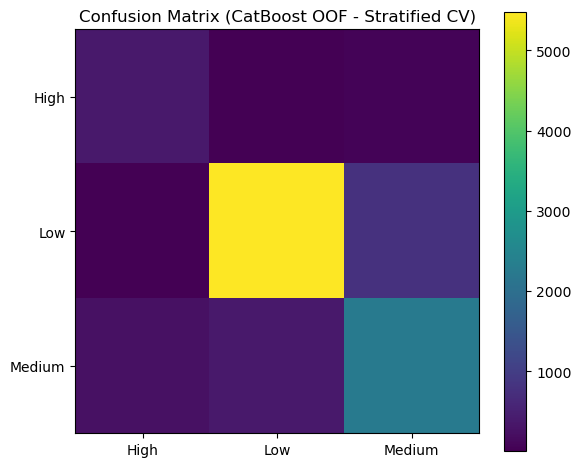

In [18]:
# OOF diagnostics: classification report + confusion matrix

oof_pred = cv_strat["oof_pred"]

print("OOF Macro F1:", macro_f1(y, oof_pred))
print(classification_report(y, oof_pred))

labels = sorted(y.unique())
cm = confusion_matrix(y, oof_pred, labels=labels)

cm_df = pd.DataFrame(cm, index=[f"true_{c}" for c in labels],
                        columns=[f"pred_{c}" for c in labels])
display(cm_df)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix (CatBoost OOF - Stratified CV)")
plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)
plt.colorbar()
plt.tight_layout()
plt.show()

The CatBoost model achieved strong out-of-fold performance with macro F1 ≈ `0.783`. The confusion matrix reveals that most errors occur between adjacent financial health categories `(Low ↔ Medium and Medium ↔ High)`, which is expected given the ordinal nature of financial well-being. Importantly, the model rarely confuses extreme categories `(Low vs High)`, indicating that it has learned meaningful structural patterns in the data. Overall, CatBoost significantly outperforms linear baselines and demonstrates strong capability in handling mixed categorical and numeric survey data.

,feature,importance
34,funeral_insurance,18.343548
19,has_credit_card,6.229297
28,has_loan_account,5.982864
30,has_debit_card,5.050384
36,uses_friends_family_savings,4.246269
29,has_internet_banking,3.619537
13,has_mobile_money,2.929632
22,perception_insurance_important,2.867099
33,medical_insurance,2.765045
23,has_insurance,2.750048


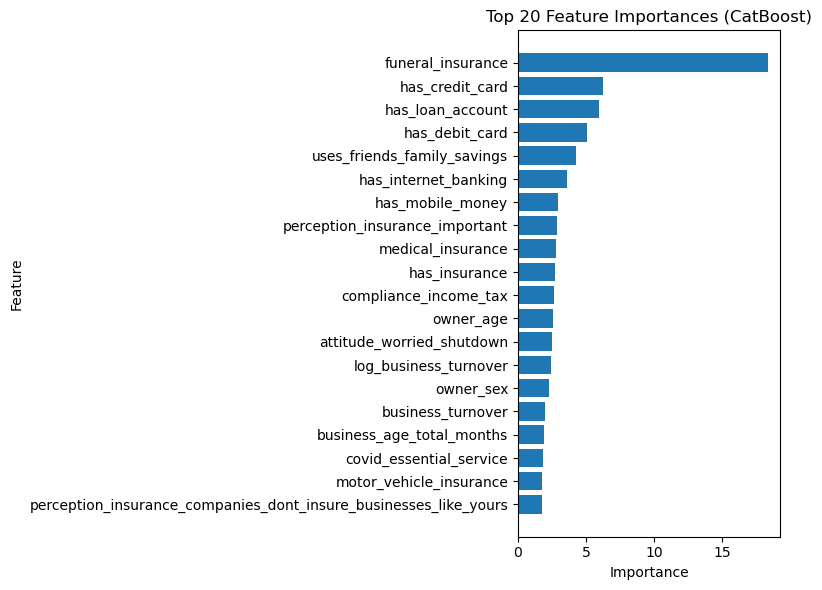

In [20]:
# Feature importance

# Use the best fold model (or first model)
best_fold = int(np.argmax(cv_strat["fold_scores"]))
best_model = cv_strat["models"][best_fold]

importances = best_model.get_feature_importance()
fi = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

display(fi.head(30))

plt.figure(figsize=(8, 6))
plt.barh(fi.head(20)["feature"][::-1], fi.head(20)["importance"][::-1])
plt.title("Top 20 Feature Importances (CatBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Feature importance analysis reveals that financial inclusion variables such as **funeral insurance**, **credit cards**, **loan accounts**, and **digital banking** tools are among the strongest predictors of SME financial health. Interestingly, these signals outperform traditional business size indicators such as turnover and expenses. This finding aligns with the conceptual design of the Financial Health Index, which emphasizes resilience and financial system integration rather than simple revenue measures.

In [23]:
# Train final model on full training data & generate submission

# Ensure test has the same categorical handling as training
test_cb = test.copy()
for c in cat_cols:
    test_cb[c] = test_cb[c].astype("string").fillna("missing")

# Train on full training data
final_model = CatBoostClassifier(**cat_params)

full_pool = Pool(X_cb, y, cat_features=cat_feature_indices)
final_model.fit(full_pool, verbose=200)

# Predict on CLEANED test
test_pred = final_model.predict(test_cb)
test_pred = np.asarray(test_pred).reshape(-1)  # make 1D

submission = pd.DataFrame({
    "ID": test_cb[ID],
    "Target": test_pred
})

submission.to_csv("submission_catboost.csv", index=False)
submission.head()

0:	learn: 0.7594695	total: 258ms	remaining: 21m 27s
200:	learn: 0.8703972	total: 1m 11s	remaining: 28m 22s
400:	learn: 0.8972856	total: 2m 24s	remaining: 27m 35s
600:	learn: 0.9174060	total: 3m 33s	remaining: 26m 5s
800:	learn: 0.9346923	total: 4m 47s	remaining: 25m 5s
1000:	learn: 0.9465450	total: 5m 59s	remaining: 23m 54s
1200:	learn: 0.9537572	total: 6m 57s	remaining: 22m
1400:	learn: 0.9613713	total: 7m 57s	remaining: 20m 26s
1600:	learn: 0.9649494	total: 8m 56s	remaining: 18m 59s
1800:	learn: 0.9692031	total: 10m 5s	remaining: 17m 54s
2000:	learn: 0.9736755	total: 11m 14s	remaining: 16m 50s
2200:	learn: 0.9776015	total: 12m 30s	remaining: 15m 54s
2400:	learn: 0.9807648	total: 13m 34s	remaining: 14m 41s
2600:	learn: 0.9832230	total: 14m 32s	remaining: 13m 25s
2800:	learn: 0.9851948	total: 15m 30s	remaining: 12m 10s
3000:	learn: 0.9877478	total: 16m 44s	remaining: 11m 9s
3200:	learn: 0.9894022	total: 17m 44s	remaining: 9m 58s
3400:	learn: 0.9914256	total: 18m 42s	remaining: 8m 47s
3

,ID,Target
0,ID_5EGLKX,Low
1,ID_4AI7RE,Low
2,ID_V9OB3M,Low
3,ID_6OI9DI,Low
4,ID_H2TN8B,Low


## Model Card — CatBoost (Model 1)

**Objective:** Predict SME Financial Health Index (Low/Medium/High) using survey + business features.

**Why CatBoost?**
- Handles high-cardinality categorical variables natively (no OHE explosion).
- Captures nonlinear interactions and threshold effects.
- Robust to missing values common in survey data.

**Validation:**
- **StratifiedKFold (main):** estimates performance under similar train/test country mixture.
- **GroupKFold by country (diagnostic):** stress test for cross-country generalization (domain shift).

**Key Findings:**
- Tree models dramatically outperform linear baselines.
- Country grouping reduces performance, confirming domain shift.
- Feature importance highlights access-to-finance and resilience variables as strong signals.

**Next Iterations:**
- Hyperparameter tuning (depth, learning rate, l2, subsample).
- Compare `class_weights` strategies.
- Country-aware calibration or interaction engineering.
- Try LightGBM as Model 2 and ensemble with CatBoost.